In [31]:
# Polynomial ANOVA: fit mpg ~ horsepower (degrees 1..5) and compare with anova_lm
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Load Auto dataset
url = 'https://raw.githubusercontent.com/fedscornell/MachineLearning25/main/Auto.csv'
auto = pd.read_csv(url)

models = {}
for deg in range(1, 6):
    terms = ['I(horsepower**%d)' % p for p in range(1, deg + 1)]
    formula = 'mpg ~ ' + ' + '.join(terms)
    models[deg] = smf.ols(formula, data=auto).fit()
    print(f'Fitted degree {deg}: R^2 = {models[deg].rsquared:.4f}')

anova_results = []
for deg in range(1, 5):
    m_reduced = models[deg]
    m_full = models[deg+1]
    print('\nANOVA: degree %d vs %d' % (deg, deg+1))
    a = anova_lm(m_reduced, m_full)
    print(a)
    try:
        f_stat = a['F'].iloc[1]
        p_val = a['Pr(>F)'].iloc[1]
    except Exception:
        f_stat = np.nan
        p_val = np.nan
    anova_results.append((deg, deg+1, f_stat, p_val))

# Report cubic vs quartic
for d1, d2, f_stat, p_val in anova_results:
    if d1 == 3 and d2 == 4:
        print('\nCubic vs Quartic:')
        print(f'F = {f_stat:.6f}, p = {p_val:.6g}')
        break

# Decide justified degree by sequential p < 0.05
justified = 1
for d1, d2, f_stat, p_val in anova_results:
    if not np.isnan(p_val) and p_val < 0.05:
        justified = d2
    else:
        break
print(f'\nPolynomial degree justified by ANOVA (alpha=0.05): {justified}')

Fitted degree 1: R^2 = 0.6059
Fitted degree 2: R^2 = 0.6876
Fitted degree 3: R^2 = 0.6882
Fitted degree 4: R^2 = 0.6893
Fitted degree 5: R^2 = 0.6967

ANOVA: degree 1 vs 2
   df_resid          ssr  df_diff     ss_diff           F        Pr(>F)
0     390.0  9385.915872      0.0         NaN         NaN           NaN
1     389.0  7442.029412      1.0  1943.88646  101.608283  2.196340e-21

ANOVA: degree 2 vs 3
   df_resid          ssr  df_diff    ss_diff        F    Pr(>F)
0     389.0  7442.029412      0.0        NaN      NaN       NaN
1     388.0  7426.436007      1.0  15.593405  0.81469  0.367297

ANOVA: degree 3 vs 4
   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0     388.0  7426.436007      0.0        NaN       NaN       NaN
1     387.0  7399.522632      1.0  26.913375  1.407588  0.236185

ANOVA: degree 4 vs 5
   df_resid          ssr  df_diff     ss_diff         F    Pr(>F)
0     387.0  7399.522632      0.0         NaN       NaN       NaN
1     386.0  7223.371686   

In [32]:
# Regression spline with B-splines on Boston: medv ~ bs(lstat) using internal knots [10,20,30]
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP import load_data

# Load Boston dataset
Boston = load_data('Boston')
if 'MEDV' not in Boston.columns and 'medv' in Boston.columns:
    Boston['MEDV'] = Boston['medv']
if 'LSTAT' not in Boston.columns and 'lstat' in Boston.columns:
    Boston['LSTAT'] = Boston['lstat']

X = Boston[['LSTAT']].values
y = Boston['MEDV'].values

# Use patsy.bs to build B-spline basis; fallback to sklearn if unavailable
try:
    from patsy import dmatrix
    expr = 'bs(LSTAT, knots=(10,20,30), degree=3, include_intercept=True) - 1'
    X_basis = dmatrix(expr, data=Boston, return_type='dataframe')
    basis_name = 'patsy.bs'
except Exception:
    from sklearn.preprocessing import SplineTransformer
    knots = np.array([10.,20.,30.]).reshape(-1,1)
    spline = SplineTransformer(degree=3, knots=knots, include_bias=True)
    arr = spline.fit_transform(X)
    X_basis = pd.DataFrame(arr, columns=[f'bs_{i}' for i in range(arr.shape[1])])
    basis_name = 'sklearn.SplineTransformer'

# Fit OLS
X_design = sm.add_constant(X_basis, has_constant='add')
model = sm.OLS(y, X_design).fit()
print('B-spline basis builder used:', basis_name)
print('B-spline basis shape:', X_basis.shape)
print('Number of basis functions (columns):', X_basis.shape[1])
print('OLS R-squared:', model.rsquared)

B-spline basis builder used: patsy.bs
B-spline basis shape: (506, 7)
Number of basis functions (columns): 7
OLS R-squared: 0.6834878749017888


Basis builder used: patsy.cr
Basis shape: (263, 4)
Number of basis functions (columns): 4
OLS R-squared: 0.2638024661127155


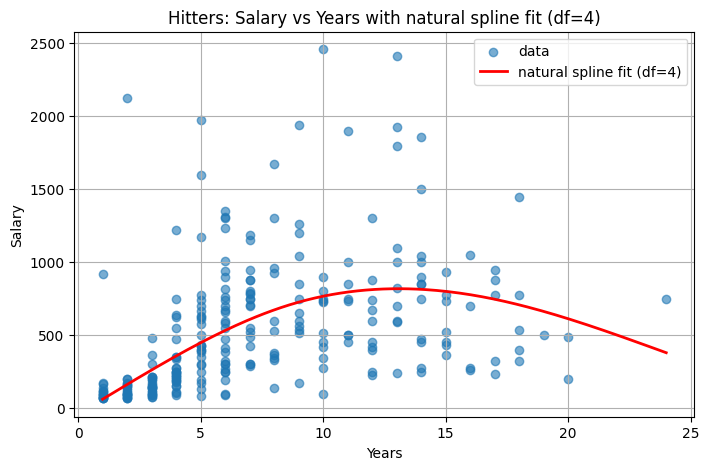

In [33]:
# Natural spline (Hitters): Salary ~ ns(Years, df=4) and plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data

Hitters = load_data('Hitters').dropna()
if 'Salary' not in Hitters.columns and 'salary' in Hitters.columns:
    Hitters['Salary'] = Hitters['salary']
if 'Years' not in Hitters.columns and 'years' in Hitters.columns:
    Hitters['Years'] = Hitters['years']

X = Hitters[['Years']].copy()
y = Hitters['Salary'].values

try:
    from ISLP.models import ns
    X_basis = ns(X['Years'], df=4, intercept=False)
    X_basis = pd.DataFrame(X_basis, index=X.index)
    basis_name = 'ISLP.models.ns'
except Exception:
    from patsy import dmatrix
    X_basis = dmatrix('cr(Years, df=4) - 1', data=Hitters, return_type='dataframe')
    basis_name = 'patsy.cr'

X_design = sm.add_constant(X_basis, has_constant='add')
model = sm.OLS(y, X_design).fit()
print('Basis builder used:', basis_name)
print('Basis shape:', X_basis.shape)
print('Number of basis functions (columns):', X_basis.shape[1])
print('OLS R-squared:', model.rsquared)

# Plot fitted curve
xx = np.linspace(X['Years'].min(), X['Years'].max(), 200)
if basis_name == 'ISLP.models.ns':
    Xx_basis = ns(xx, df=4, intercept=False)
    Xx_basis = pd.DataFrame(Xx_basis)
else:
    from patsy import dmatrix
    Xx_basis = dmatrix('cr(xx, df=4) - 1', {'xx': xx}, return_type='dataframe')
Xx_design = sm.add_constant(Xx_basis, has_constant='add')
yy = model.predict(Xx_design)
plt.figure(figsize=(8,5))
plt.scatter(X['Years'], y, alpha=0.6, label='data')
plt.plot(xx, yy, color='red', lw=2, label='natural spline fit (df=4)')
plt.xlabel('Years')
plt.ylabel('Salary')
plt.title('Hitters: Salary vs Years with natural spline fit (df=4)')
plt.legend()
plt.grid(True)
plt.show()

Training R-squared (.score()): 0.5142227904413001


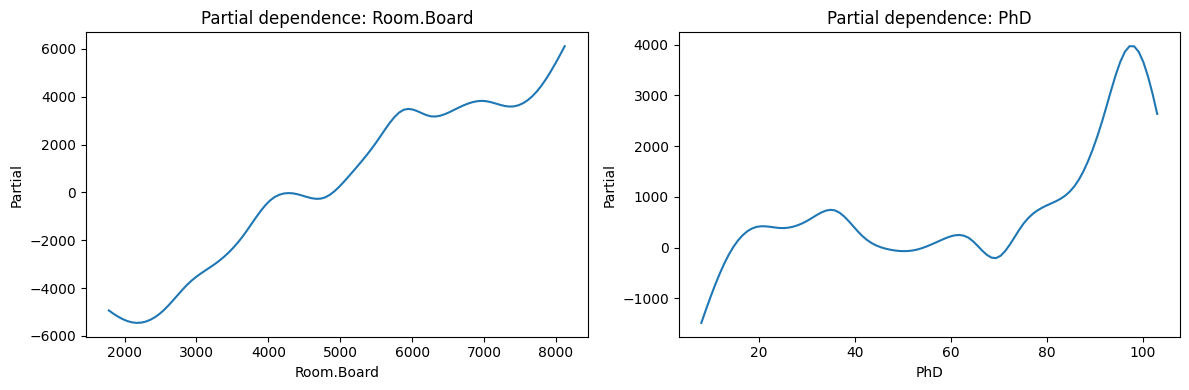

In [34]:
# GAM on College: Outstate ~ s(Room.Board) + s(PhD) using pygam LinearGAM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data

College = load_data('College')
if 'Outstate' not in College.columns and 'outstate' in College.columns:
    College['Outstate'] = College['outstate']
if 'Room.Board' not in College.columns and 'room.board' in College.columns:
    College['Room.Board'] = College['room.board']
if 'PhD' not in College.columns and 'phd' in College.columns:
    College['PhD'] = College['phd']

X = College[['Room.Board','PhD']].values
y = College['Outstate'].values

try:
    from pygam import LinearGAM, s
except Exception as e:
    raise ImportError('pygam is required for this cell. Install with: pip install pygam') from e

gam = LinearGAM(s(0) + s(1)).fit(X, y)
r2 = gam.score(X, y)
print('Training R-squared (.score()):', r2)

# Partial dependence plots (pygam or ISLP helper)
feature_names = ['Room.Board','PhD']
try:
    from ISLP.pygam import plot_gam
    fig, axs = plot_gam(gam, feature_names=feature_names)
except Exception:
    fig, axs = plt.subplots(1,2,figsize=(12,4))
    for i, ax in enumerate(axs):
        grid = gam.generate_X_grid(term=i)
        xvals = grid[:, i]
        pdep = gam.partial_dependence(term=i, X=grid)
        ax.plot(xvals, pdep)
        ax.set_xlabel(feature_names[i])
        ax.set_ylabel('Partial')
        ax.set_title(f'Partial dependence: {feature_names[i]}')
    plt.tight_layout()
    plt.show()

In [36]:
# Step function on Carseats: Sales ~ step(Price) with 4 bins
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP import load_data

Carseats = load_data('Carseats').copy()
# Normalize column names if needed
if 'Price' not in Carseats.columns and 'price' in Carseats.columns:
    Carseats['Price'] = Carseats['price']
if 'Sales' not in Carseats.columns and 'sales' in Carseats.columns:
    Carseats['Sales'] = Carseats['sales']

# Create 4 bins for Price (equal-width by default)
Carseats['Price_bin'] = pd.cut(Carseats['Price'], bins=4)
categories = Carseats['Price_bin'].cat.categories
# Ensure dummy columns are numeric (float) to avoid object/bool dtype issues with statsmodels
dummies = pd.get_dummies(Carseats['Price_bin'], prefix='Price_bin', drop_first=True, dtype=float)
X = dummies
# Ensure response is numeric
y = Carseats['Sales'].astype(float)
# Add constant and cast to float to avoid dtype issues
X_design = sm.add_constant(X, has_constant='add').astype(float)
model = sm.OLS(y, X_design).fit()
print('Coefficient estimates:')
print(model.params.to_string())
print('\nModel R-squared: {:.6f}'.format(model.rsquared))

coef_dummies = model.params.drop('const')
most_negative = coef_dummies.idxmin()
most_negative_val = coef_dummies[most_negative]
print('\nBin with strongest negative effect on Sales: {} (coef = {:.4f})'.format(most_negative, most_negative_val))

print('\nPrice bin intervals (categories):')
for i, cat in enumerate(categories):
    print(f'{i}: {cat}')

print('\nDummy column -> bin interval mapping (first category is reference and omitted):')
for col in dummies.columns:
    interval = col.replace('Price_bin_', '')
    print(f'{col} -> {interval}')

Coefficient estimates:
const                        10.960000
Price_bin_(65.75, 107.5]     -2.301295
Price_bin_(107.5, 149.25]    -4.006532
Price_bin_(149.25, 191.0]    -5.504375

Model R-squared: 0.147841

Bin with strongest negative effect on Sales: Price_bin_(149.25, 191.0] (coef = -5.5044)

Price bin intervals (categories):
0: (23.833, 65.75]
1: (65.75, 107.5]
2: (107.5, 149.25]
3: (149.25, 191.0]

Dummy column -> bin interval mapping (first category is reference and omitted):
Price_bin_(65.75, 107.5] -> (65.75, 107.5]
Price_bin_(107.5, 149.25] -> (107.5, 149.25]
Price_bin_(149.25, 191.0] -> (149.25, 191.0]
